#### Depth-Aware Image Dehazing - Demo

This notebook demonstrates inference using our trained dehazing models.

#### Models:
1. AOD-Net (baseline)
2. FFA-Net (baseline)
3. AOD-Net + Depth Concatenation
4. Depth-Guided Attention
5. Joint Multi-Task Learning

#### Requirements:
- PyTorch
- torchvision
- PIL
- matplotlib
- numpy

In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

import sys
sys.path.append('.')

from src.models import AODNet, FFANet, DepthGuidedFFANet, JointDehazeDepthNet

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [3]:
def load_image(path, size=256):
    img = Image.open(path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])
    return transform(img).unsqueeze(0)

def tensor_to_image(tensor):
    img = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    return img

def load_depth(image_tensor):
    midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True)
    midas.eval().to(device)
    
    midas_transforms = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
    
    img_np = (image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    
    input_batch = midas_transforms.small_transform(img_np).to(device)
    
    with torch.no_grad():
        depth = midas(input_batch)
        depth = depth.squeeze().cpu().numpy()
    
    depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
    depth = torch.from_numpy(depth).unsqueeze(0).unsqueeze(0).float()
    
    depth = torch.nn.functional.interpolate(depth, size=(256, 256), mode='bilinear', align_corners=False)
    
    return depth.to(device)

In [6]:
models = {}

# AOD-Net baseline
model = AODNet(in_channels=3)
ckpt = torch.load('experiments/aodnet_baseline/checkpoints/best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
models['AOD-Net'] = (model.to(device).eval(), 'baseline')
print("  AOD-Net loaded")

# FFA-Net baseline
model = FFANet(in_channels=3)
ckpt = torch.load('experiments/ffanet_baseline/checkpoints/best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
models['FFA-Net'] = (model.to(device).eval(), 'baseline')
print("  FFA-Net loaded")

# Depth Concatenation
model = AODNet(in_channels=4)
ckpt = torch.load('experiments/aodnet_depth_concat/checkpoints/best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
models['Depth-Concat'] = (model.to(device).eval(), 'concat')
print("  Depth-Concat loaded")

# Depth Attention
model = DepthGuidedFFANet(in_channels=3, channels=64, num_groups=3, num_blocks=6,
                           attention_type='learned', injection_points=['middle'])
ckpt = torch.load('experiments/depth_attention/checkpoints/best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
models['Depth-Attn'] = (model.to(device).eval(), 'attention')
print("  Depth-Attention loaded")

# Joint Multi-Task
model = JointDehazeDepthNet(in_channels=3, base_channels=32)
ckpt = torch.load('experiments/depth_joint/checkpoints/best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
models['Joint'] = (model.to(device).eval(), 'joint')
print("  Joint model loaded")

print("\nModels loaded")

  AOD-Net loaded
  FFA-Net loaded
  Depth-Concat loaded
  Depth-Attention loaded
  Joint model loaded

Models loaded


In [8]:
# Load sample hazy image
hazy_path = 'sample_images/sots_hazy.jpg'
hazy = load_image(hazy_path).to(device)

# Estimate depth
print("Estimating depth")
depth = load_depth(hazy)

# Run all models
print("Running inference")
outputs = {'Hazy Input': tensor_to_image(hazy)}

with torch.no_grad():
    for name, (model, mtype) in models.items():
        if mtype == 'baseline':
            out = model(hazy)
        elif mtype == 'concat':
            out = model(torch.cat([hazy, depth], dim=1))
        elif mtype == 'attention':
            out = model(hazy, depth)
        elif mtype == 'joint':
            out, _ = model(hazy)
        outputs[name] = tensor_to_image(out)
        print(f"  {name} done")

Estimating depth
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /Users/sejalbarshikar/.cache/torch/hub/master.zip


/opt/homebrew/Caskroom/miniconda/base/envs/dehazing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/miniconda/base/envs/dehazing/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /Users/sejalbarshikar/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /Users/sejalbarshikar/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /Users/sejalbarshikar/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:08<00:00, 10.7MB/s]
Using cache found in /Users/sejalbarshikar/.cache/torch/hub/intel-isl_MiDaS_master


Running inference
  AOD-Net done
  FFA-Net done
  Depth-Concat done
  Depth-Attn done
  Joint done


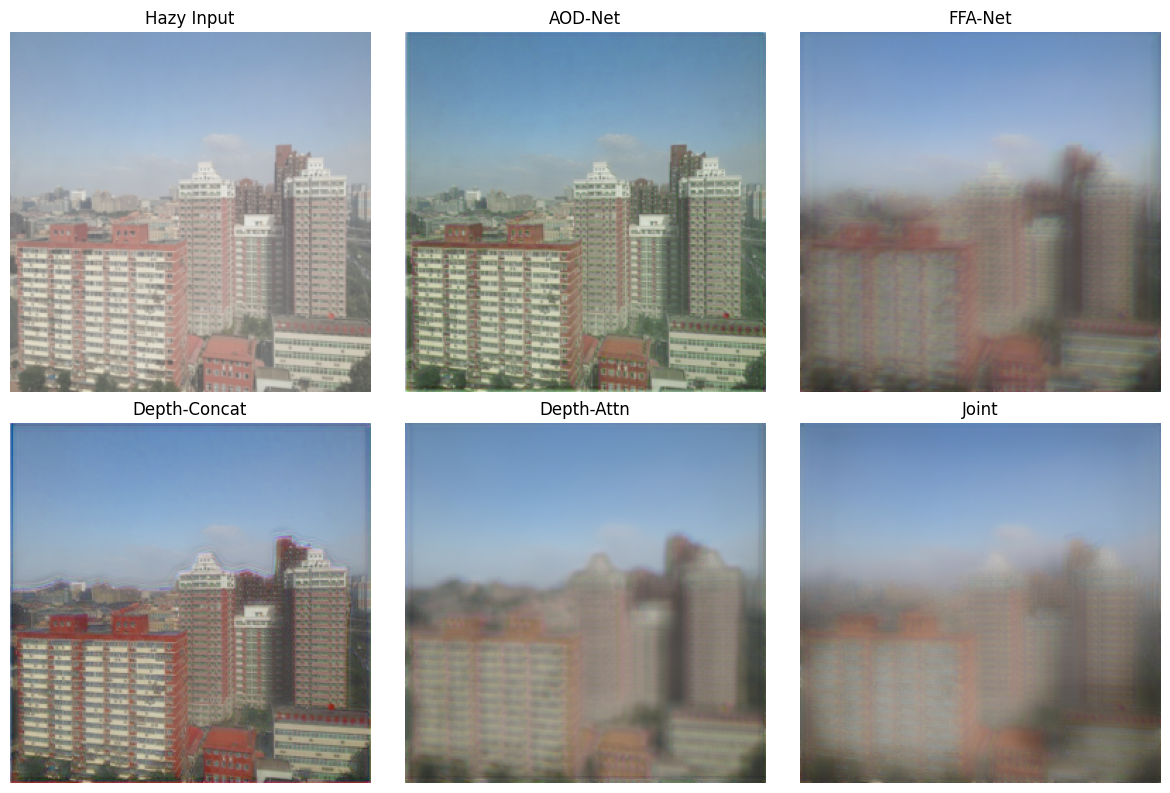


Output saved to demo_output.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (name, img) in enumerate(outputs.items()):
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('demo_output.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOutput saved to demo_output.png")

Using cache found in /Users/sejalbarshikar/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /Users/sejalbarshikar/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /Users/sejalbarshikar/.cache/torch/hub/intel-isl_MiDaS_master


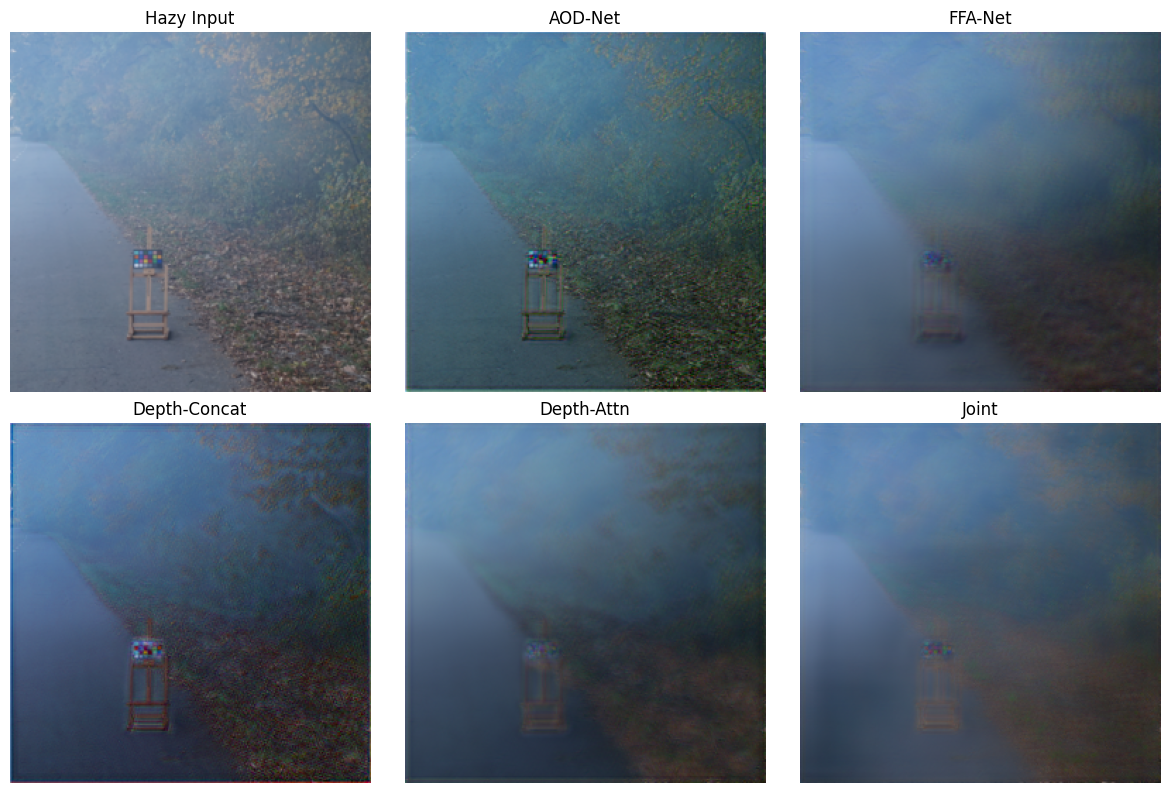

In [10]:
hazy_path2 = 'sample_images/ohaze_hazy.jpg'
hazy2 = load_image(hazy_path2).to(device)
depth2 = load_depth(hazy2)

outputs2 = {'Hazy Input': tensor_to_image(hazy2)}

with torch.no_grad():
    for name, (model, mtype) in models.items():
        if mtype == 'baseline':
            out = model(hazy2)
        elif mtype == 'concat':
            out = model(torch.cat([hazy2, depth2], dim=1))
        elif mtype == 'attention':
            out = model(hazy2, depth2)
        elif mtype == 'joint':
            out, _ = model(hazy2)
        outputs2[name] = tensor_to_image(out)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (name, img) in enumerate(outputs2.items()):
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
